## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez TEAMS w wiadomości prywatnej.

## Regresja liniowa prosta

Regresja liniowa prosta, to szczególny przypadek regresji liniowej, w którym zmienną objaśnaną przewidujemy za pomocą jednej zmiennej objaśniającej. Zadanie będzie polegało na wyznaczeniu funkcji regresji opisującej zależność zarobków od lat doświadczenia. 

Zbiór danych do tego zadania, to Salary.csv. Znajduje się w katalogu datasets.
W zbiorze danych znajduje się 35 obserwacji. Każdy wpis jest osobną obserwacją. W zbiorze znajdują się 3 kolumny: YearsExperience, Age i Salary. W pierwszym zadaniu należy wykorzystać YearsExperience i Salary, pomijając Age.

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### Zadanie 1

Wczytaj dane z pliku Salary.csv, a następnie stwórz wykres przedstawiający obserwacje.

In [2]:
#YOUR CODE HERE
data = pd.read_csv('./Salary.csv', delimiter=',')
data.head()

,YearsExperience,Age,Salary
0,1.1,20,39343
1,1.3,21,46205
2,1.5,21,37731
3,2.0,22,43525
4,2.2,22,39891


In [3]:
data.describe()

,YearsExperience,Age,Salary
count,35.000000,35.000000,35.000000
mean,6.308571,28.371429,83888.428571
std,3.618610,5.568217,32200.112889
min,1.100000,20.000000,37731.000000
25%,3.450000,24.000000,57019.000000
50%,5.300000,27.000000,81363.000000
75%,9.250000,32.500000,113223.500000
max,13.500000,40.000000,139465.000000


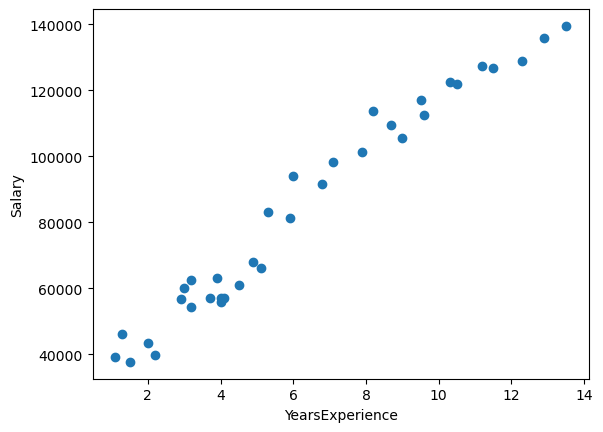

In [4]:
x = data['YearsExperience']
y = data['Salary']

plt.scatter(x, y)
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [5]:
x.shape

(35,)

In [6]:
y.shape

(35,)

In [7]:
len(x)

35

In [8]:
type(x)
#x = x.values

pandas.core.series.Series

In [9]:
x

0      1.1
1      1.3
2      1.5
3      2.0
4      2.2
5      2.9
6      3.0
7      3.2
8      3.2
9      3.7
10     3.9
11     4.0
12     4.0
13     4.1
14     4.5
15     4.9
16     5.1
17     5.3
18     5.9
19     6.0
20     6.8
21     7.1
22     7.9
23     8.2
24     8.7
25     9.0
26     9.5
27     9.6
28    10.3
29    10.5
30    11.2
31    11.5
32    12.3
33    12.9
34    13.5
Name: YearsExperience, dtype: float64

**Bazowo było x.reshape(-1, 1), zwraca błąd ponieważ x było series, a metoda działa tylko na numpy array (python 3.12)**

In [10]:
x1 = x.values.reshape(-1, 1)
x1

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5],
       [11.2],
       [11.5],
       [12.3],
       [12.9],
       [13.5]])

### Zadanie 2

Implementacja algorytmu regresji liniowej prostej.

Żeby dobrze zrozumieć zapis matematyczny, który początkowo może sprawiać problemy, przejdziemy po kolei po elementach składowych algorytmu. Następnie złączymy elementy w całość.

Wzór na regresję liniową w naszym przypadku będzie wyglądał następująco:

\begin{equation}
f(x^{(i)}) = \beta_{0} + \beta_{1}x_1 = \beta_{0} + \beta_{1}  YearsExperience
\end{equation}

Przypomnijmy, że zapis $x^{(i)}$ oznacza wektor dla $i$-tej obserwacji. W naszym przypadku ten wektor będzie zawierał tylko $1$ wartość dla cechy $YearsExperience$.


_Uwaga: W różnych źródłach algorytm regresji liniowej ma różne zapisy. Czasem podawane są wzory w postaci z sumą, czasem w postaci macierzowej. Jest to spowodowane tym, że algorytm można zaimplementować na te dwa sposoby. Łatwiejszym i bardziej intuicyjnym podejściem jest podejście z sumą, która bezpośrednio sugeruje wykokrzystanie pętli w celu iteracji po obserwacjach/cechach. Implementacja z wykorzystaniem macierzy jest zwykle krótsza i "bardziej elegancka", ale również bardziej wydajna. Aby dobrze zrozumieć działanie algorytmu, najlepiej jest zaimplementować obie wersje i porównać je ze sobą._


#### 2.1 Inicjalizacja współczynników $\beta$ regresji

Pierwszym krokiem jest inicjalizacja współczynników regresji. W przypadku regresji liniowej prostej mamy dwa współczynniki $\beta_{0}$ i $\beta_{1}$. Stwórz dwie zmienne będące współczynnikami regresji liniowej prostej i zainicjalizuj je losowymi wartościami z przedziału $(0,1)$.

Dodatkowo stwórz zmienną *alpha*, która przyjmie wartość od $(0,1)$. Możesz ustawić ją ręcznie i sprawdzać jak różne wartości mają wpływ na regresję. 

In [11]:
def initialize_coefficients(alpha: float = 0.01) -> Tuple[float, float, float]:
    eps = np.finfo(float).eps
    beta0 = np.random.uniform(eps, 1 - eps)  # niedomknięte przedziały
    beta1 = np.random.uniform(eps, 1 - eps)
    alpha = alpha  #np.random.uniform(eps, 1 - eps)
    return beta0, beta1, alpha

#### 2.2 Obliczenie predykcji

Kolejnym krokiem jest obliczenie wartości funkcji regresji dla wszystkich obserwacji w zbiorze danych. Jest to po prostu wstawienie kolejnych wartości pod wzrór regresji.

\begin{equation}
f(x) = \beta_{0} + \beta_{1}x_1
\end{equation}

Można zrobić to z wykorzystaniem operacji na macierzach (wektorach), albo z wykorzystaniem klasycznej iteracji. 

In [12]:
def calculate_regression_function(x: np.ndarray, beta0: float, beta1: float) -> np.ndarray:
    return beta0 + x * beta1

#### 2.3 Obliczenie błędu

Obliczenie wartości błędu regresji nie jest konieczne do aktualizacji wag, jednak jest to bardzo cenna informacja czy nasz algorytm działa poprawnie. Wartość błędu nie może rosnąć w kolejnych epokach.

Błąd należy obliczyć zgodnie ze wzorem:

\begin{equation}
    SSR = \frac{1}{2m} \sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)})^2
\end{equation}

In [13]:
def calculate_error(predictions: np.ndarray, y: np.ndarray) -> float:
    m = len(predictions)
    return (1.0 / (2 * m)) * np.sum((predictions - y) ** 2)


**Beta0 oraz Beta1 były wskazane jako parametry ale moim zdaniem nie są tutaj do niczego potrzebne**

#### 2.4 Obliczenie gradientu 

Żeby obliczyć gradient, należy obliczyć pochodne cząstkowe względem parametrów $\beta_{0}$ i $\beta_{1}$.

\begin{equation}
    \frac{\partial SSR}{\partial \beta_{0}} = \frac{1}{m} \sum^{m}_{i=1} (f(x^{(i)}) - y^{(i)})
\end{equation}

\begin{equation}
    \frac{\partial SSR}{\partial \beta_{1}} = \frac{1}{m} \sum^{m}_{i=1} (f(x^{(i)}) - y^{(i)})x_{1}^{(i)}
\end{equation}

Tutaj ponownie jak wcześniej można wykorzystać operacje na macierzach, lub iteracyjnie obliczyć sumę.

In [14]:
def calculate_gradient(x: np.array, predictions: np.ndarray, y: np.ndarray) -> Tuple[
    float, float]:
    m = len(predictions)
    error = predictions - y
    d_beta0 = (1.0 / m) * np.sum(error)
    d_beta1 = (1.0 / m) * np.sum(error * x)
    return d_beta0, d_beta1



**W parametrach brakowało x, który zgodnie ze wzorem jest konieczny do policzenia gradientu. Parametry beta0 i beta1 nie były tutaj konieczne**

####  2.5 Aktualizacja współczynników regresji (wag)

Po obliczeniu pochodnych cząstkowych należy obliczyć nowe wartości dla współczynników regresji.


\begin{equation}
    \beta_{0} = \beta_{0} - \alpha \frac{\partial SSR}{\partial \beta_{0}} 
\end{equation}

\begin{equation}
    \beta_{1} = \beta_{1} - \alpha \frac{\partial SSR}{\partial \beta_{1}} 
\end{equation}

In [15]:
def update_regression_coefficients(x: np.ndarray, predictions: np.ndarray, y: np.ndarray, beta0: float, beta1: float,
                                   alpha: float) -> Tuple[
    float, float]:
    d_beta0, d_beta1 = calculate_gradient(x, predictions, y)
    beta0_new = beta0 - alpha * d_beta0
    beta1_new = beta1 - alpha * d_beta1
    return beta0_new, beta1_new


#### 2.6 Finalna wersja algorytmu

Powyższe działania, to wszystkie elementy potrzebne do stworzenia algorytmu regresji liniowej prostej. Jeden cykl takich operacji nazywany jest **epoką**. Idea obliczania współczynników regresji z wykorzystaniem gradientu polega na iteracyjnym aktualizowaniu współczynników do momentu, aż błąd przestanie znacznie się zmieniać. Można również ustawić jakaś stałą ilość epok. W każdej epoce wykorzystuje się ponownie ten sam zestaw danych.

Skoro wiadomo już jakie pojedyncze etapy należy wykonać, żeby obliczyć regresję liniową prostą, przyszedł czas na zebranie wszystkiego w jednym miejscu.

Proszę zaimplementować funkcję `learn_and_fit(x, y)`, która dla danych wejściowych będzie zwracać współczynniki regresji w każdej z epok. Dodatkowo proszę zwracać również błąd regresji w każdej epoce. Funkcja może być zaimplementowana w dowolny sposób. Może bezpośrednio zawierać wszystkie instrukcje, może korzystać z innych funkcji pomocniczych albo może korzystać z klasy reprezentującą regresję liniową prostą. 

Na końcu notebooka znajduje się test jednostkowy, który musi przechodzić przy prawidłowej implementacji algorytmu.

In [20]:
'''
input:
x - wartości zmiennej objaśniającej YearsExperience dla wszystkich obserwacji
y - wartości zmiennej objaśnianej Salary dla wszystkich obserwacji
stop - zamierzona wartość błędu
alpha

output:
b0: [] - lista z współczynnikami beta_0 w każdej z epok
b1: [] - lista z współczynnikami beta_1 w każdej z epok
error: [] - lista z błędem w każdej epoce
'''


def learn_and_fit(x: np.ndarray, y: np.ndarray, stop: float = 0.0001, alpha: float = 0.01) -> Tuple[
    np.ndarray, np.ndarray, np.ndarray]:
    epoch = 1500
    b0_list = []
    b1_list = []
    errors_list = []
    beta0, beta1, alpha = initialize_coefficients(alpha)
    for ep in range(epoch):
        y_pred = calculate_regression_function(x, beta0, beta1)
        err = calculate_error(y_pred, y)
        beta0, beta1 = update_regression_coefficients(x, y_pred, y, beta0, beta1, alpha)
        b0_list.append(beta0)
        b1_list.append(beta1)
        errors_list.append(err)
        if err < stop:
            print(f'Błąd został osiągnięty przy epoce {ep}')
            break
    return np.array(b0_list), np.array(b1_list), np.array(errors_list)


### Zadanie 3

Stwórz wykres zmiany błędu regresji (oś Y) względem epoki (oś X)

In [21]:
b0, b1, err = learn_and_fit(x, y)

Text(0.5, 1.0, 'Zmiana błedu regresji względem epoki - skala logarytmiczna')

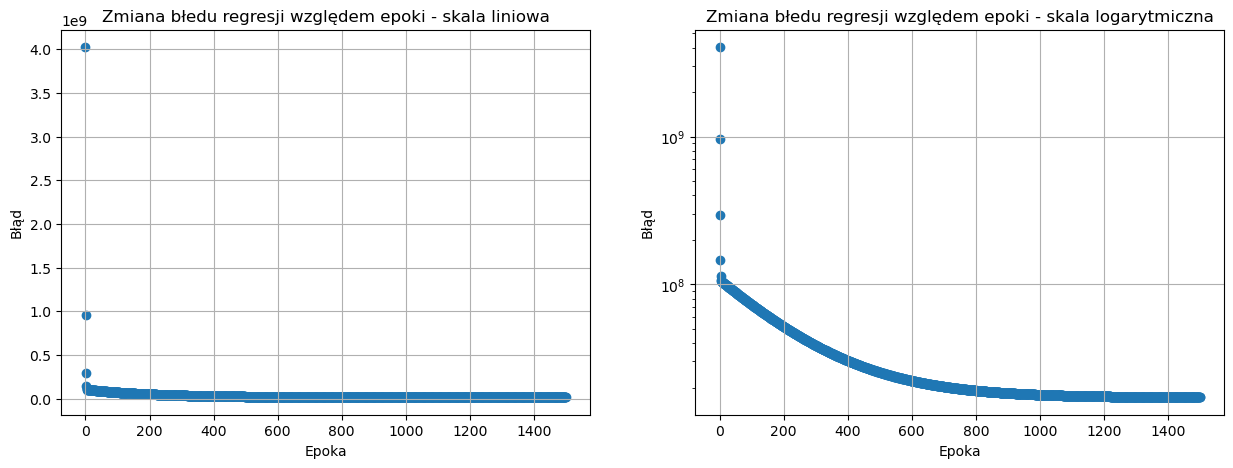

In [22]:
# YOUR CODE HERE
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(range(len(err)), err)
ax[0].set_xlabel('Epoka')
ax[0].set_ylabel('Błąd')
ax[0].grid(True)
ax[0].set_title('Zmiana błedu regresji względem epoki - skala liniowa')

ax[1].scatter(range(1500), err)
ax[1].set_yscale('log')
ax[1].set_xlabel('Epoka')
ax[1].set_ylabel('Błąd')
ax[1].grid(True)
ax[1].set_title('Zmiana błedu regresji względem epoki - skala logarytmiczna')


### Zadanie 4

Do wykresu stworzonego w zadaniu 1 dodaj prostą regresji. Stwórz 3 wykresy przedstawiające jak zmieniała się funkcja regresji na przestrzeni epok (pierwsza, środkowa, ostatnia epoka).

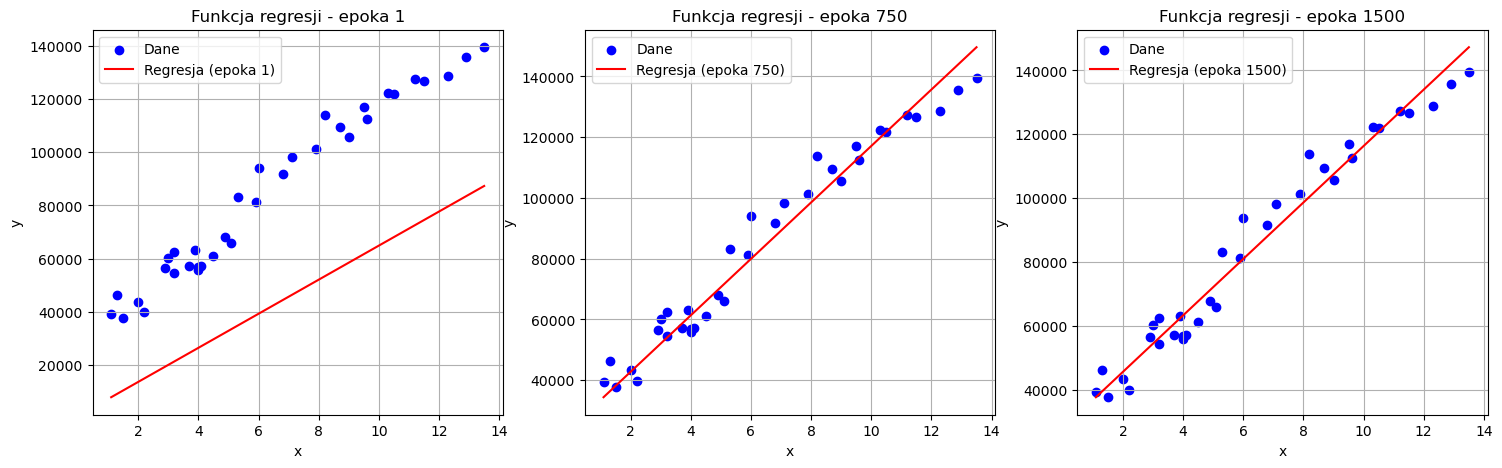

In [23]:
epochs = len(err)

middle_idx = (0 + (epochs - 1)) // 2
epoch_indices = [0, middle_idx, epochs - 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, idx in enumerate(epoch_indices):
    beta0 = b0[idx]
    beta1 = b1[idx]

    y_pred_line = beta0 + beta1 * x

    axes[i].scatter(x, y, color='blue', label='Dane')
    axes[i].plot(x, y_pred_line, color='red', label=f'Regresja (epoka {idx + 1})')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].set_title(f'Funkcja regresji - epoka {idx + 1}')
    axes[i].legend()
    axes[i].grid(True)



In [24]:
fig, ax = plt.subplots(figsize=(4, 4))
scat = ax.scatter(x, y, color='blue', label='Dane')
line, = ax.plot([], [], color='red', label='Regresja')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Zmiana funkcji regresji na przestrzeni epok')
ax.legend()
ax.grid(True)


def init():
    line.set_data([], [])
    return line,


def update(frame):
    beta0 = b0[frame]
    beta1 = b1[frame]
    y_pred = beta0 + beta1 * x
    line.set_data(x, y_pred)
    ax.set_title(f'Epoka {frame + 1} / {epochs}, Błąd: {err[frame]:.4f}')
    return line,


frame_indices = range(0, epochs, 100)

ani = FuncAnimation(fig, update, frames=frame_indices, init_func=init, blit=True, interval=300)
plt.close(fig)
HTML(ani.to_jshtml())

### Zadanie 5

Wybierz dowolnie trzy różne wartości współczynnika $\alpha$. Ile epok mu zostać użytych żeby otrzymać zamierzoną wartość błędu?

In [29]:
# YOUR CODE HERE
alpha_list = [0.001, 0.005, 0.01, 0.02, 0.08]

for alpha in alpha_list:
    print(f'Dla alpha = {alpha}')
    learn_and_fit(x, y, 70000000, alpha)

Dla alpha = 0.001
Błąd został osiągnięty przy epoce 1114
Dla alpha = 0.005
Błąd został osiągnięty przy epoce 223
Dla alpha = 0.01
Błąd został osiągnięty przy epoce 112
Dla alpha = 0.02
Błąd został osiągnięty przy epoce 56
Dla alpha = 0.08
Błąd został osiągnięty przy epoce 588


/Users/kubanskan/miniconda3/envs/pk-machine-learning/lib/python3.12/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/var/folders/bb/m3bx4_9533n3h0xhv96spdv40000gn/T/ipykernel_94468/1171578117.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  beta1_new = beta1 - alpha * d_beta1


**Dla zbyt małego alpha algorytm zbiega do rozwiązania zbyt wolno, dla alpha które jest zbyt duże przeskakujemy minimum i błędy zaczynają rosnąć co powoduje błąd.**

### Testy jednostkowe

In [30]:
import unittest
import pandas as pd


class SimpleLinearRegressionTest(unittest.TestCase):

    def test_learn_and_fit(self):
        df = pd.read_csv('Salary.csv', sep=',')
        x = df['YearsExperience'].values.reshape(df['YearsExperience'].shape[0], 1)
        y = df['Salary'].values.reshape(df['Salary'].shape[0], 1)

        b0, b1, error = learn_and_fit(x, y)

        self.assertTrue(len(b0) > 1)
        self.assertTrue(len(b1) > 1)
        self.assertTrue(len(b0) == len(b1))
        self.assertTrue(all(i >= j for i, j in zip(error, error[1:])))  #Sprawdzenie, czy błędy nie rosną


unittest.main(argv=[''], verbosity=2, exit=False)

test_learn_and_fit (__main__.SimpleLinearRegressionTest.test_learn_and_fit) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.018s

OK


### Zadanie 6

Stwórz test jednostkowy sprawdzający czy funkcja inicjalizująca współczynniki regresji zwraca wartości z przedziału (0, 1)

In [31]:
class SimpleLinearRegressionTest(unittest.TestCase):
    def test_initialize_coefficients(self):
        beta0, beta1, alpha = initialize_coefficients()

        self.assertTrue(0 < beta0 < 1, f"beta0={beta0} nie jest w (0,1)")
        self.assertTrue(0 < beta1 < 1, f"beta1={beta1} nie jest w (0,1)")


unittest.main(argv=[''], verbosity=2, exit=False)

test_initialize_coefficients (__main__.SimpleLinearRegressionTest.test_initialize_coefficients) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK
